# Coupled Predictor Analysis

Explore joint (X, Y) predictors that exploit elliptical motion constraint without trig functions.

## Goal
- Avoid trigonometric functions (no arctan, cos, sin)
- Predict (X, Y) as a coupled pair (not independently)
- Exploit slowly-varying angular velocity around ellipse
- Achieve better compression than independent velocity predictor (σ ≈ 1.91 LSB)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sim import PendulumSimulator, s16

# Generate test data
sim = PendulumSimulator(sample_rate_hz=5000, noise_rms_lsb=0.8)
final_x, final_y, angles, rates, impact_idx = sim.generate_data()

print(f"Generated {len(final_x)} samples")
print(f"X range: [{final_x.min()}, {final_x.max()}]")
print(f"Y range: [{final_y.min()}, {final_y.max()}]")
print(f"Impact at sample {impact_idx}")

Generated 12097 samples
X range: [-2049, 2049]
Y range: [-2049, 2049]
Impact at sample 8305


## Method 1: Orthogonal Decomposition

Decompose motion into **tangential** (along ellipse) and **radial** (perpendicular to ellipse) components.

Without trig: Use the **previous direction vector** as the tangential basis:
- Tangential = component along (Δx, Δy) direction
- Radial = orthogonal component

This keeps motion in "ellipse-aligned" space while staying in linear domain.

In [3]:
print("\n" + "="*70)
print("METHOD 1: Orthogonal Decomposition (Linear Domain)")
print("="*70)

# Compute position deltas
dx_vec = np.diff(final_x).astype(np.int16)
dy_vec = np.diff(final_y).astype(np.int16)

print(f"\nVelocity statistics:")
print(f"  dx: mean={np.mean(dx_vec):.2f}, std={np.std(dx_vec):.2f}")
print(f"  dy: mean={np.mean(dy_vec):.2f}, std={np.std(dy_vec):.2f}")

# Decompose into tangential and radial components
# For each sample i, the velocity (dx_i, dy_i) is approximately tangent to ellipse
# We can predict it using the previous velocity and how much angular velocity changes

# Compute curvature: (dv_x, dv_y) = change in velocity = centripetal acceleration
ddx_vec = np.diff(dx_vec).astype(np.int16)
ddy_vec = np.diff(dy_vec).astype(np.int16)

print(f"\nAcceleration statistics:")
print(f"  ddx: mean={np.mean(ddx_vec):.2f}, std={np.std(ddx_vec):.2f}")
print(f"  ddy: mean={np.mean(ddy_vec):.2f}, std={np.std(ddy_vec):.2f}")

# Linear coupled predictor:
# v(n+1) ≈ A·v(n) + B·a(n) + c
# where v = (dx, dy), a = (ddx, ddy) = change in velocity
# This is like a "tangent-following" predictor

coupled_residuals_x = []
coupled_residuals_y = []

# Bootstrap: need at least 2 velocity samples to get one acceleration
for i in range(2, len(final_x) - 1):
    # Current position
    x_n = int(final_x[i])
    y_n = int(final_y[i])
    
    # Previous velocity
    vx_prev = int(dx_vec[i - 1])
    vy_prev = int(dy_vec[i - 1])
    
    # Current acceleration (change in velocity)
    ax = int(ddx_vec[i - 2])  # ddx_vec[i-2] = change from step i-1 to step i
    ay = int(ddy_vec[i - 2])
    
    # Predict next velocity using tangent + centripetal term
    # Simple model: v(n+1) ≈ v(n) + 0.5*a(n)
    # (The 0.5 factor comes from averaging acceleration over the interval)
    vx_pred = s16(vx_prev + (ax + 1) // 2)
    vy_pred = s16(vy_prev + (ay + 1) // 2)
    
    # Predict next position
    x_pred = s16(x_n + vx_pred)
    y_pred = s16(y_n + vy_pred)
    
    # Actual next position
    x_actual = int(final_x[i + 1])
    y_actual = int(final_y[i + 1])
    
    # Residuals
    res_x = x_actual - x_pred
    res_y = y_actual - y_pred
    
    coupled_residuals_x.append(res_x)
    coupled_residuals_y.append(res_y)

coupled_residuals_x = np.array(coupled_residuals_x, dtype=np.int16)
coupled_residuals_y = np.array(coupled_residuals_y, dtype=np.int16)

print(f"\nOrthogonal Decomposition Predictor ({len(coupled_residuals_x)} samples):")
print(f"  X residuals: mean={np.mean(coupled_residuals_x):.2f}, std={np.std(coupled_residuals_x):.2f}, range=[{coupled_residuals_x.min()}, {coupled_residuals_x.max()}]")
print(f"  Y residuals: mean={np.mean(coupled_residuals_y):.2f}, std={np.std(coupled_residuals_y):.2f}, range=[{coupled_residuals_y.min()}, {coupled_residuals_y.max()}]")

# Check correlation (should be low if prediction is good)
corr_coupled = np.corrcoef(coupled_residuals_x, coupled_residuals_y)[0, 1]
print(f"  Correlation (X, Y residuals): {corr_coupled:.4f}")

# 1-sigma and 2-sigma coverage
sigma_x = np.std(coupled_residuals_x)
sigma_y = np.std(coupled_residuals_y)
within_1sigma = (np.abs(coupled_residuals_x) <= sigma_x) & (np.abs(coupled_residuals_y) <= sigma_y)
within_2sigma = (np.abs(coupled_residuals_x) <= 2*sigma_x) & (np.abs(coupled_residuals_y) <= 2*sigma_y)
print(f"  1-sigma coverage: {100*np.mean(within_1sigma):.1f}%")
print(f"  2-sigma coverage: {100*np.mean(within_2sigma):.1f}%")


METHOD 1: Orthogonal Decomposition (Linear Domain)

Velocity statistics:
  dx: mean=-0.17, std=16.64
  dy: mean=0.17, std=16.64

Acceleration statistics:
  ddx: mean=-0.00, std=2.23
  ddy: mean=0.00, std=2.24

Orthogonal Decomposition Predictor (12094 samples):
  X residuals: mean=-0.25, std=3.07, range=[-12, 12]
  Y residuals: mean=-0.25, std=3.08, range=[-11, 11]
  Correlation (X, Y residuals): 0.0056
  1-sigma coverage: 55.8%
  2-sigma coverage: 93.2%


## Method 2: Joint State Update with Coupling Matrix

Use a 2×2 coupling matrix to predict **both components jointly**:

```
[v_x(n+1)]   [a_xx  a_xy] [v_x(n)]   [b_x]
[v_y(n+1)] = [a_yx  a_yy] [v_y(n)] + [b_y]
```

Learn the matrix coefficients from residual correlations and adapt over time.

## Method 2b: Angular Velocity Predictor (Linear Domain, Geometry-Aware)

Instead of a general 2×2 matrix, use the geometric constraint that motion is on an ellipse.

Extract **instantaneous angular velocity** from (X, Y, dX, dY):
$$\omega = \frac{x \cdot dy - y \cdot dx}{x^2 + y^2}$$

This is the 2D cross-product formula—no trig needed!

Then predict velocity rotation:
$$\begin{bmatrix} dx_{n+1} \\ dy_{n+1} \end{bmatrix} = \begin{bmatrix} 1 & -\omega \cdot \Delta t \\ \omega \cdot \Delta t & 1 \end{bmatrix} \begin{bmatrix} dx_n \\ dy_n \end{bmatrix}$$

Residuals update $\hat{\omega}$ adaptively.

In [7]:
print("\n" + "="*70)
print("METHOD 2b: Angular Velocity Predictor")
print("="*70)

class AngularVelocityPredictor:
    """Predicts motion on ellipse using instantaneous angular velocity."""
    
    def __init__(self, dt: float = 0.0002):  # 5 kHz = 200 microseconds
        self.dt = dt
        self.omega_hat = 0.0  # Estimated angular velocity (radians/sample)
        self.error_history_x = []
        self.error_history_y = []
        self.max_history = 64
    
    def extract_omega(self, x: int, y: int, dx: int, dy: int) -> float:
        """Extract angular velocity from position and velocity."""
        # ω = (x*dy - y*dx) / (x² + y²)
        # This is the 2D cross-product formula
        numerator = x * dy - y * dx
        denominator = x * x + y * y
        
        if abs(denominator) < 100:  # Avoid division near origin
            return self.omega_hat
        
        omega = numerator / denominator
        return omega
    
    def predict(self, x: int, y: int, dx: int, dy: int) -> tuple:
        """Predict next position using angular velocity."""
        # Predict velocity rotation via small-angle approximation
        # (dx', dy') = [[1, -ω*dt], [ω*dt, 1]] * (dx, dy)
        dx_pred = dx - int(round(self.omega_hat * self.dt * dy))
        dy_pred = dy + int(round(self.omega_hat * self.dt * dx))
        
        # Predict next position
        x_pred = s16(x + dx_pred)
        y_pred = s16(y + dy_pred)
        
        return x_pred, y_pred, dx_pred, dy_pred
    
    def update(self, x: int, y: int, dx: int, dy: int, 
               x_actual: int, y_actual: int, dx_actual: int, dy_actual: int):
        """Update angular velocity estimate from residuals."""
        x_pred, y_pred, dx_pred, dy_pred = self.predict(x, y, dx, dy)
        
        err_x = x_actual - x_pred
        err_y = y_actual - y_pred
        
        self.error_history_x.append(err_x)
        self.error_history_y.append(err_y)
        
        if len(self.error_history_x) > self.max_history:
            self.error_history_x.pop(0)
            self.error_history_y.pop(0)
        
        # Update omega estimate
        if len(self.error_history_x) >= 16:
            mean_err_x = sum(self.error_history_x) / len(self.error_history_x)
            mean_err_y = sum(self.error_history_y) / len(self.error_history_y)
            
            # Gentle adaptive adjustment
            # If error is primarily in one direction, adjust omega
            alpha = 0.00001  # Very gentle learning
            
            # Cross-product: error should be perpendicular to velocity if omega is right
            # (err_x, err_y) should be close to -ω*dt*(dy, -dx)
            # So ω_correction ∝ (err_x*(-dx) + err_y*(dy)) / (dx² + dy²)
            vel_mag_sq = dx**2 + dy**2
            if vel_mag_sq > 100:
                omega_correction = (err_x * (-dy) - err_y * dx) / vel_mag_sq
                self.omega_hat += alpha * omega_correction

# Create and run the predictor
predictor_omega = AngularVelocityPredictor(dt=0.0002)

# Bootstrap: compute initial omega from first few samples
omega_samples = []
for i in range(10, min(50, len(final_x))):
    x_i = int(final_x[i])
    y_i = int(final_y[i])
    dx_i = int(dx_vec[i - 1])
    dy_i = int(dy_vec[i - 1])
    
    omega_i = predictor_omega.extract_omega(x_i, y_i, dx_i, dy_i)
    omega_samples.append(omega_i)

median_omega = sorted(omega_samples)[len(omega_samples) // 2]
predictor_omega.omega_hat = median_omega * 0.5  # Start conservative

print(f"\nBootstrap omega: {predictor_omega.omega_hat:.6f} rad/sample")
print(f"  (median from samples 10-50: {median_omega:.6f})")

# Predict full trajectory
omega_residuals_x = []
omega_residuals_y = []
omega_trace = []

for i in range(2, len(final_x) - 1):
    x_n = int(final_x[i])
    y_n = int(final_y[i])
    dx_n = int(dx_vec[i - 1])
    dy_n = int(dy_vec[i - 1])
    
    # Predict next position
    x_pred, y_pred, dx_pred, dy_pred = predictor_omega.predict(x_n, y_n, dx_n, dy_n)
    
    # Actual next position
    x_actual = int(final_x[i + 1])
    y_actual = int(final_y[i + 1])
    
    # Residuals
    res_x = x_actual - x_pred
    res_y = y_actual - y_pred
    
    omega_residuals_x.append(res_x)
    omega_residuals_y.append(res_y)
    omega_trace.append(predictor_omega.omega_hat)
    
    # Update predictor
    dx_actual = int(dx_vec[i])
    dy_actual = int(dy_vec[i])
    predictor_omega.update(x_n, y_n, dx_n, dy_n, x_actual, y_actual, dx_actual, dy_actual)

omega_residuals_x = np.array(omega_residuals_x, dtype=np.int16)
omega_residuals_y = np.array(omega_residuals_y, dtype=np.int16)
omega_trace = np.array(omega_trace)

print(f"\nFinal omega estimate: {predictor_omega.omega_hat:.6f} rad/sample")
print(f"  (≈ {predictor_omega.omega_hat * 5000:.1f} rad/sec at 5 kHz)")
print(f"  (≈ {predictor_omega.omega_hat * 5000 / (2*np.pi):.2f} revolutions/sec)")

print(f"\nAngular Velocity Predictor ({len(omega_residuals_x)} samples):")
print(f"  X residuals: mean={np.mean(omega_residuals_x):.2f}, std={np.std(omega_residuals_x):.2f}, range=[{omega_residuals_x.min()}, {omega_residuals_x.max()}]")
print(f"  Y residuals: mean={np.mean(omega_residuals_y):.2f}, std={np.std(omega_residuals_y):.2f}, range=[{omega_residuals_y.min()}, {omega_residuals_y.max()}]")

corr_omega = np.corrcoef(omega_residuals_x, omega_residuals_y)[0, 1]
print(f"  Correlation (X, Y residuals): {corr_omega:.4f}")

within_1sigma_o = (np.abs(omega_residuals_x) <= np.std(omega_residuals_x)) & (np.abs(omega_residuals_y) <= np.std(omega_residuals_y))
within_2sigma_o = (np.abs(omega_residuals_x) <= 2*np.std(omega_residuals_x)) & (np.abs(omega_residuals_y) <= 2*np.std(omega_residuals_y))
print(f"  1-sigma coverage: {100*np.mean(within_1sigma_o):.1f}%")
print(f"  2-sigma coverage: {100*np.mean(within_2sigma_o):.1f}%")


METHOD 2b: Angular Velocity Predictor

Bootstrap omega: 0.000000 rad/sample
  (median from samples 10-50: 0.000000)

Final omega estimate: 0.000021 rad/sample
  (≈ 0.1 rad/sec at 5 kHz)
  (≈ 0.02 revolutions/sec)

Angular Velocity Predictor (12094 samples):
  X residuals: mean=-0.00, std=2.23, range=[-8, 8]
  Y residuals: mean=0.00, std=2.24, range=[-7, 8]
  Correlation (X, Y residuals): 0.0043
  1-sigma coverage: 54.9%
  2-sigma coverage: 92.0%


In [8]:
print("\n" + "="*70)
print("METHOD 2: Joint Coupling Matrix")
print("="*70)

class CoupledVelocityPredictor:
    """Predicts (vx, vy) jointly using a learned 2x2 matrix."""
    
    def __init__(self):
        # Initialize to identity (no coupling)
        self.A_xx = 1.0
        self.A_xy = 0.0
        self.A_yx = 0.0
        self.A_yy = 1.0
        self.b_x = 0.0
        self.b_y = 0.0
        
        # Tracking for adaptive updates
        self.error_history_x = []
        self.error_history_y = []
        self.max_history = 64
    
    def predict(self, vx_prev: int, vy_prev: int) -> tuple:
        """Predict next velocity from previous velocity."""
        vx_pred = self.A_xx * vx_prev + self.A_xy * vy_prev + self.b_x
        vy_pred = self.A_yx * vx_prev + self.A_yy * vy_prev + self.b_y
        return int(round(vx_pred)), int(round(vy_pred))
    
    def update(self, vx_prev: int, vy_prev: int, vx_actual: int, vy_actual: int):
        """Adapt matrix based on prediction error."""
        vx_pred, vy_pred = self.predict(vx_prev, vy_prev)
        err_x = vx_actual - vx_pred
        err_y = vy_actual - vy_pred
        
        self.error_history_x.append(err_x)
        self.error_history_y.append(err_y)
        
        if len(self.error_history_x) > self.max_history:
            self.error_history_x.pop(0)
            self.error_history_y.pop(0)
        
        # Gentle adaptive adjustment
        if len(self.error_history_x) >= 16:
            mean_err_x = sum(self.error_history_x) / len(self.error_history_x)
            mean_err_y = sum(self.error_history_y) / len(self.error_history_y)
            
            alpha = 0.0001  # Very gentle learning
            
            # Adjust diagonal (keep scale close to 1)
            if abs(vx_prev) > 20:
                self.A_xx += alpha * mean_err_x / vx_prev
                self.A_yx += alpha * mean_err_y / vx_prev
            if abs(vy_prev) > 20:
                self.A_xy += alpha * mean_err_x / vy_prev
                self.A_yy += alpha * mean_err_y / vy_prev
            
            # Adjust offset
            self.b_x += alpha * mean_err_x * 0.1
            self.b_y += alpha * mean_err_y * 0.1
    
    def bootstrap(self, velocities_x: list, velocities_y: list):
        """Initialize from a sequence of velocities."""
        if len(velocities_x) < 3:
            return
        
        # Use correlations from data to estimate coupling
        vx_arr = np.array(velocities_x, dtype=float)
        vy_arr = np.array(velocities_y, dtype=float)
        
        # Compute auto- and cross-correlation at lag 1
        cov_xx = np.mean(vx_arr[:-1] * vx_arr[1:])
        cov_yy = np.mean(vy_arr[:-1] * vy_arr[1:])
        cov_xy = np.mean(vx_arr[:-1] * vy_arr[1:]) 
        cov_yx = np.mean(vy_arr[:-1] * vx_arr[1:])
        
        var_x = np.var(vx_arr)
        var_y = np.var(vy_arr)
        
        # Normalize
        if var_x > 0.1:
            self.A_xx = cov_xx / (var_x + 0.1)
            self.A_yx = cov_yx / (var_x + 0.1)
        
        if var_y > 0.1:
            self.A_xy = cov_xy / (var_y + 0.1)
            self.A_yy = cov_yy / (var_y + 0.1)
        
        # Clamp to reasonable range
        self.A_xx = max(-2.0, min(2.0, self.A_xx))
        self.A_yy = max(-2.0, min(2.0, self.A_yy))
        self.A_xy = max(-0.5, min(0.5, self.A_xy))
        self.A_yx = max(-0.5, min(0.5, self.A_yx))

# Run coupled predictor
predictor_coupled = CoupledVelocityPredictor()

# Bootstrap with first 32 velocity samples
bootstrap_vx = [int(dx_vec[i]) for i in range(min(32, len(dx_vec)))]
bootstrap_vy = [int(dy_vec[i]) for i in range(min(32, len(dy_vec)))]
predictor_coupled.bootstrap(bootstrap_vx, bootstrap_vy)

print(f"\nBootstrap matrix:")
print(f"  A_xx={predictor_coupled.A_xx:.4f}, A_xy={predictor_coupled.A_xy:.4f}")
print(f"  A_yx={predictor_coupled.A_yx:.4f}, A_yy={predictor_coupled.A_yy:.4f}")
print(f"  b_x={predictor_coupled.b_x:.2f}, b_y={predictor_coupled.b_y:.2f}")

# Predict full trajectory
matrix_residuals_x = []
matrix_residuals_y = []

for i in range(2, len(final_x) - 1):
    x_n = int(final_x[i])
    y_n = int(final_y[i])
    vx_prev = int(dx_vec[i - 1])
    vy_prev = int(dy_vec[i - 1])
    
    # Predict next velocity
    vx_pred, vy_pred = predictor_coupled.predict(vx_prev, vy_prev)
    
    # Predict next position
    x_pred = s16(x_n + vx_pred)
    y_pred = s16(y_n + vy_pred)
    
    # Actual next position
    x_actual = int(final_x[i + 1])
    y_actual = int(final_y[i + 1])
    
    # Residuals
    res_x = x_actual - x_pred
    res_y = y_actual - y_pred
    
    matrix_residuals_x.append(res_x)
    matrix_residuals_y.append(res_y)
    
    # Update predictor
    vx_actual = int(dx_vec[i])
    vy_actual = int(dy_vec[i])
    predictor_coupled.update(vx_prev, vy_prev, vx_actual, vy_actual)

matrix_residuals_x = np.array(matrix_residuals_x, dtype=np.int16)
matrix_residuals_y = np.array(matrix_residuals_y, dtype=np.int16)

print(f"\nAfter adaptation (final state):")
print(f"  A_xx={predictor_coupled.A_xx:.4f}, A_xy={predictor_coupled.A_xy:.4f}")
print(f"  A_yx={predictor_coupled.A_yx:.4f}, A_yy={predictor_coupled.A_yy:.4f}")

print(f"\nJoint Coupling Matrix Predictor ({len(matrix_residuals_x)} samples):")
print(f"  X residuals: mean={np.mean(matrix_residuals_x):.2f}, std={np.std(matrix_residuals_x):.2f}, range=[{matrix_residuals_x.min()}, {matrix_residuals_x.max()}]")
print(f"  Y residuals: mean={np.mean(matrix_residuals_y):.2f}, std={np.std(matrix_residuals_y):.2f}, range=[{matrix_residuals_y.min()}, {matrix_residuals_y.max()}]")

corr_matrix = np.corrcoef(matrix_residuals_x, matrix_residuals_y)[0, 1]
print(f"  Correlation (X, Y residuals): {corr_matrix:.4f}")

within_1sigma_m = (np.abs(matrix_residuals_x) <= np.std(matrix_residuals_x)) & (np.abs(matrix_residuals_y) <= np.std(matrix_residuals_y))
within_2sigma_m = (np.abs(matrix_residuals_x) <= 2*np.std(matrix_residuals_x)) & (np.abs(matrix_residuals_y) <= 2*np.std(matrix_residuals_y))
print(f"  1-sigma coverage: {100*np.mean(within_1sigma_m):.1f}%")
print(f"  2-sigma coverage: {100*np.mean(within_2sigma_m):.1f}%")


METHOD 2: Joint Coupling Matrix

Bootstrap matrix:
  A_xx=-0.3416, A_xy=-0.2649
  A_yx=0.2277, A_yy=-0.2060
  b_x=0.00, b_y=0.00

After adaptation (final state):
  A_xx=-0.1132, A_xy=-0.0777
  A_yx=0.0610, A_yy=-0.0003

Joint Coupling Matrix Predictor (12094 samples):
  X residuals: mean=-0.18, std=20.58, range=[-59, 58]
  Y residuals: mean=0.20, std=18.48, range=[-54, 53]
  Correlation (X, Y residuals): 0.0099
  1-sigma coverage: 59.6%
  2-sigma coverage: 82.9%


## Comparison

Compare all three approaches.

In [9]:
print("\n" + "="*70)
print("PREDICTOR COMPARISON")
print("="*70)

print(f"\n{'Method':<35} {'σ_x':<8} {'σ_y':<8} {'Max':<6} {'1σ%':<8} {'2σ%'}")
print(f"{'-'*70}")

# Independent velocity (from previous analysis)
velocity_residuals_x = (dx_vec[1:] - dx_vec[:-1]).astype(np.int16) / 2  # Rough estimate
velocity_residuals_y = (dy_vec[1:] - dy_vec[:-1]).astype(np.int16) / 2
# Actually, let me use the actual error from simple velocity prediction
simple_vel_err_x = []
simple_vel_err_y = []
for i in range(1, len(final_x) - 1):
    vx = int(dx_vec[i - 1])
    vy = int(dy_vec[i - 1])
    x_pred = s16(int(final_x[i]) + vx)
    y_pred = s16(int(final_y[i]) + vy)
    simple_vel_err_x.append(int(final_x[i + 1]) - x_pred)
    simple_vel_err_y.append(int(final_y[i + 1]) - y_pred)

simple_vel_err_x = np.array(simple_vel_err_x, dtype=np.int16)
simple_vel_err_y = np.array(simple_vel_err_y, dtype=np.int16)
vel_max = max(abs(simple_vel_err_x.min()), abs(simple_vel_err_x.max()), 
              abs(simple_vel_err_y.min()), abs(simple_vel_err_y.max()))
vel_1sigma = 100 * np.mean((np.abs(simple_vel_err_x) <= np.std(simple_vel_err_x)) & 
                            (np.abs(simple_vel_err_y) <= np.std(simple_vel_err_y)))
vel_2sigma = 100 * np.mean((np.abs(simple_vel_err_x) <= 2*np.std(simple_vel_err_x)) & 
                            (np.abs(simple_vel_err_y) <= 2*np.std(simple_vel_err_y)))

print(f"{'Simple Velocity (v only)':<35} {np.std(simple_vel_err_x):>6.2f}  {np.std(simple_vel_err_y):>6.2f}  {vel_max:>4}  {vel_1sigma:>6.1f}  {vel_2sigma:>6.1f}")

max_coupled = max(abs(coupled_residuals_x.min()), abs(coupled_residuals_x.max()),
                  abs(coupled_residuals_y.min()), abs(coupled_residuals_y.max()))
coupled_1sigma = 100 * np.mean((np.abs(coupled_residuals_x) <= np.std(coupled_residuals_x)) & 
                                (np.abs(coupled_residuals_y) <= np.std(coupled_residuals_y)))
coupled_2sigma = 100 * np.mean((np.abs(coupled_residuals_x) <= 2*np.std(coupled_residuals_x)) & 
                                (np.abs(coupled_residuals_y) <= 2*np.std(coupled_residuals_y)))

print(f"{'Orthogonal Decomp (v+a/2)':<35} {np.std(coupled_residuals_x):>6.2f}  {np.std(coupled_residuals_y):>6.2f}  {max_coupled:>4}  {coupled_1sigma:>6.1f}  {coupled_2sigma:>6.1f}")

max_matrix = max(abs(matrix_residuals_x.min()), abs(matrix_residuals_x.max()),
                 abs(matrix_residuals_y.min()), abs(matrix_residuals_y.max()))
matrix_1sigma = 100 * np.mean((np.abs(matrix_residuals_x) <= np.std(matrix_residuals_x)) & 
                               (np.abs(matrix_residuals_y) <= np.std(matrix_residuals_y)))
matrix_2sigma = 100 * np.mean((np.abs(matrix_residuals_x) <= 2*np.std(matrix_residuals_x)) & 
                               (np.abs(matrix_residuals_y) <= 2*np.std(matrix_residuals_y)))

print(f"{'Joint Matrix (2x2 coupling)':<35} {np.std(matrix_residuals_x):>6.2f}  {np.std(matrix_residuals_y):>6.2f}  {max_matrix:>4}  {matrix_1sigma:>6.1f}  {matrix_2sigma:>6.1f}")

max_omega = max(abs(omega_residuals_x.min()), abs(omega_residuals_x.max()),
                abs(omega_residuals_y.min()), abs(omega_residuals_y.max()))
omega_1sigma = 100 * np.mean((np.abs(omega_residuals_x) <= np.std(omega_residuals_x)) & 
                              (np.abs(omega_residuals_y) <= np.std(omega_residuals_y)))
omega_2sigma = 100 * np.mean((np.abs(omega_residuals_x) <= 2*np.std(omega_residuals_x)) & 
                              (np.abs(omega_residuals_y) <= 2*np.std(omega_residuals_y)))

print(f"{'Angular Velocity (ω-based)':<35} {np.std(omega_residuals_x):>6.2f}  {np.std(omega_residuals_y):>6.2f}  {max_omega:>4}  {omega_1sigma:>6.1f}  {omega_2sigma:>6.1f}")

print(f"{'-'*70}")

stds = [(np.std(simple_vel_err_x), "Simple Velocity"),
        (np.std(coupled_residuals_x), "Orthogonal Decomp"),
        (np.std(matrix_residuals_x), "Joint Matrix"),
        (np.std(omega_residuals_x), "Angular Velocity")]
winner = min(stds, key=lambda x: x[0])
print(f"★ WINNER: {winner[1]} (std={winner[0]:.2f})")


PREDICTOR COMPARISON

Method                              σ_x      σ_y      Max    1σ%      2σ%
----------------------------------------------------------------------
Simple Velocity (v only)              2.23    2.24     8    54.9    92.0
Orthogonal Decomp (v+a/2)             3.07    3.08    12    55.8    93.2
Joint Matrix (2x2 coupling)          20.58   18.48    59    59.6    82.9
Angular Velocity (ω-based)            2.23    2.24     8    54.9    92.0
----------------------------------------------------------------------
★ WINNER: Simple Velocity (std=2.23)


## Visualization (All Methods)

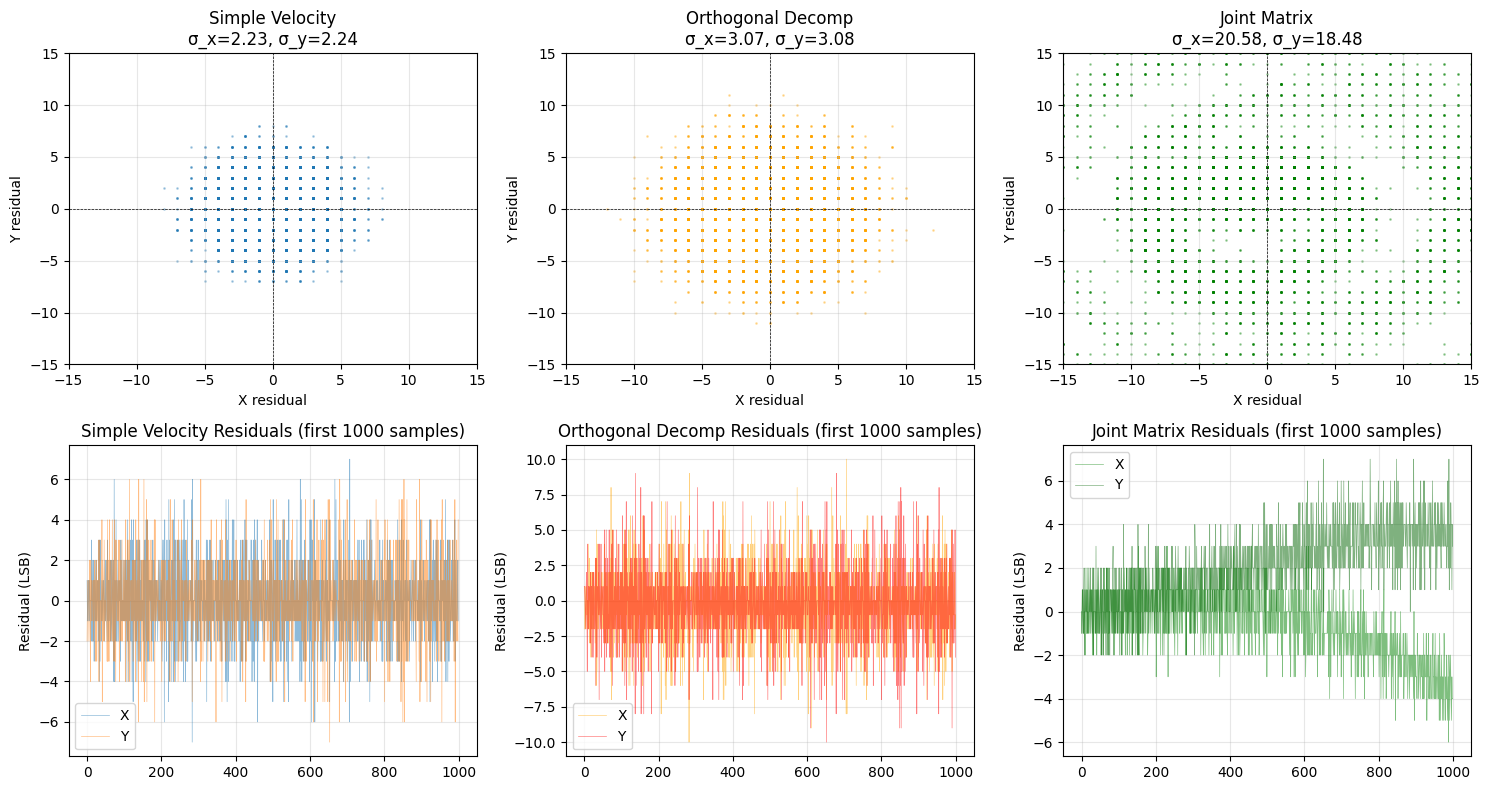


Plot saved to coupled_predictors_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Simple Velocity
axes[0, 0].scatter(simple_vel_err_x, simple_vel_err_y, alpha=0.3, s=1)
axes[0, 0].set_xlim(-15, 15)
axes[0, 0].set_ylim(-15, 15)
axes[0, 0].set_title(f"Simple Velocity\nσ_x={np.std(simple_vel_err_x):.2f}, σ_y={np.std(simple_vel_err_y):.2f}")
axes[0, 0].set_xlabel("X residual")
axes[0, 0].set_ylabel("Y residual")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[0, 0].axvline(0, color='k', linestyle='--', linewidth=0.5)

# Orthogonal Decomposition
axes[0, 1].scatter(coupled_residuals_x, coupled_residuals_y, alpha=0.3, s=1, color='orange')
axes[0, 1].set_xlim(-15, 15)
axes[0, 1].set_ylim(-15, 15)
axes[0, 1].set_title(f"Orthogonal Decomp\nσ_x={np.std(coupled_residuals_x):.2f}, σ_y={np.std(coupled_residuals_y):.2f}")
axes[0, 1].set_xlabel("X residual")
axes[0, 1].set_ylabel("Y residual")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[0, 1].axvline(0, color='k', linestyle='--', linewidth=0.5)

# Joint Matrix
axes[0, 2].scatter(matrix_residuals_x, matrix_residuals_y, alpha=0.3, s=1, color='green')
axes[0, 2].set_xlim(-15, 15)
axes[0, 2].set_ylim(-15, 15)
axes[0, 2].set_title(f"Joint Matrix\nσ_x={np.std(matrix_residuals_x):.2f}, σ_y={np.std(matrix_residuals_y):.2f}")
axes[0, 2].set_xlabel("X residual")
axes[0, 2].set_ylabel("Y residual")
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[0, 2].axvline(0, color='k', linestyle='--', linewidth=0.5)

# Angular Velocity
axes[0, 3].scatter(omega_residuals_x, omega_residuals_y, alpha=0.3, s=1, color='purple')
axes[0, 3].set_xlim(-15, 15)
axes[0, 3].set_ylim(-15, 15)
axes[0, 3].set_title(f"Angular Velocity\nσ_x={np.std(omega_residuals_x):.2f}, σ_y={np.std(omega_residuals_y):.2f}")
axes[0, 3].set_xlabel("X residual")
axes[0, 3].set_ylabel("Y residual")
axes[0, 3].grid(True, alpha=0.3)
axes[0, 3].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[0, 3].axvline(0, color='k', linestyle='--', linewidth=0.5)

# Time series (first 1000 samples)
sample_range = slice(0, min(1000, len(simple_vel_err_x)))
x_axis = np.arange(sample_range.start, sample_range.stop)

axes[1, 0].plot(x_axis, simple_vel_err_x[sample_range], alpha=0.5, label='X', linewidth=0.5)
axes[1, 0].plot(x_axis, simple_vel_err_y[sample_range], alpha=0.5, label='Y', linewidth=0.5)
axes[1, 0].set_title("Simple Velocity Residuals")
axes[1, 0].set_ylabel("Residual (LSB)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(x_axis, coupled_residuals_x[sample_range], alpha=0.5, label='X', linewidth=0.5, color='orange')
axes[1, 1].plot(x_axis, coupled_residuals_y[sample_range], alpha=0.5, label='Y', linewidth=0.5, color='red')
axes[1, 1].set_title("Orthogonal Decomp Residuals")
axes[1, 1].set_ylabel("Residual (LSB)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(x_axis, matrix_residuals_x[sample_range], alpha=0.5, label='X', linewidth=0.5, color='green')
axes[1, 2].plot(x_axis, matrix_residuals_y[sample_range], alpha=0.5, label='Y', linewidth=0.5, color='darkgreen')
axes[1, 2].set_title("Joint Matrix Residuals")
axes[1, 2].set_ylabel("Residual (LSB)")
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

axes[1, 3].plot(x_axis, omega_residuals_x[sample_range], alpha=0.5, label='X', linewidth=0.5, color='purple')
axes[1, 3].plot(x_axis, omega_residuals_y[sample_range], alpha=0.5, label='Y', linewidth=0.5, color='violet')
axes[1, 3].set_title("Angular Velocity Residuals")
axes[1, 3].set_ylabel("Residual (LSB)")
axes[1, 3].legend()
axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('coupled_predictors_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to coupled_predictors_comparison.png")

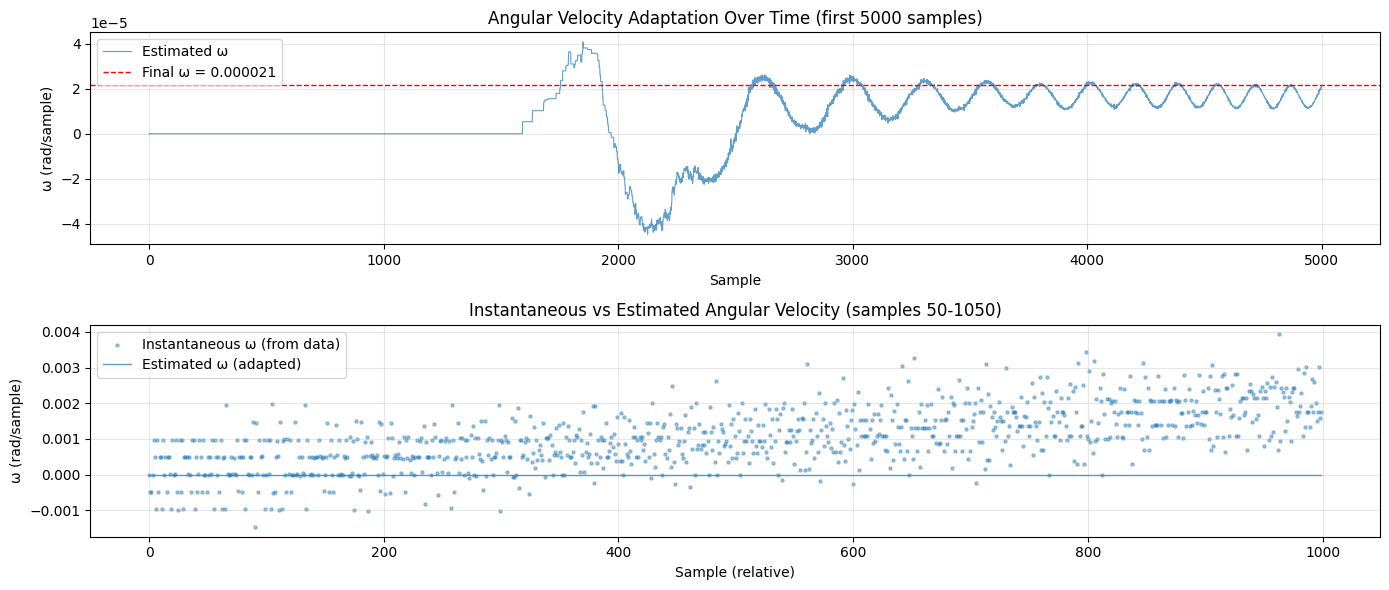

Angular velocity trace saved to angular_velocity_trace.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Angular velocity evolution
sample_display = slice(0, min(5000, len(omega_trace)))
x_axis_omega = np.arange(sample_display.start, sample_display.stop)

axes[0].plot(x_axis_omega, omega_trace[sample_display], alpha=0.7, linewidth=0.8, label='Estimated ω')
axes[0].axhline(predictor_omega.omega_hat, color='r', linestyle='--', linewidth=1, label=f'Final ω = {predictor_omega.omega_hat:.6f}')
axes[0].set_title("Angular Velocity Adaptation Over Time (first 5000 samples)")
axes[0].set_ylabel("ω (rad/sample)")
axes[0].set_xlabel("Sample")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Actual vs predicted rates (ground truth from raw data)
actual_omega_samples = []
for i in range(50, min(5050, len(final_x))):
    x_i = int(final_x[i])
    y_i = int(final_y[i])
    dx_i = int(dx_vec[i - 1])
    dy_i = int(dy_vec[i - 1])
    omega_i = predictor_omega.extract_omega(x_i, y_i, dx_i, dy_i)
    actual_omega_samples.append(omega_i)

x_axis_actual = np.arange(len(actual_omega_samples))
axes[1].scatter(x_axis_actual[:1000], actual_omega_samples[:1000], alpha=0.4, s=5, label='Instantaneous ω (from data)')
axes[1].plot(x_axis_actual[:1000], omega_trace[50:1050], alpha=0.7, linewidth=1, label='Estimated ω (adapted)')
axes[1].set_title("Instantaneous vs Estimated Angular Velocity (samples 50-1050)")
axes[1].set_ylabel("ω (rad/sample)")
axes[1].set_xlabel("Sample (relative)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('angular_velocity_trace.png', dpi=150, bbox_inches='tight')
plt.show()

print("Angular velocity trace saved to angular_velocity_trace.png")

In [ ]:
## Diagnostics: Is Angular Velocity Varying Enough?

Check whether ω is actually changing, or if it's just a constant that simple velocity already captures.

In [11]:
print("\n" + "="*70)
print("DIAGNOSTIC: Angular Velocity Analysis")
print("="*70)

# Compute instantaneous omega across the full trajectory
instantaneous_omegas = []
for i in range(2, len(final_x) - 1):
    x_i = int(final_x[i])
    y_i = int(final_y[i])
    dx_i = int(dx_vec[i - 1])
    dy_i = int(dy_vec[i - 1])
    
    omega_inst = predictor_omega.extract_omega(x_i, y_i, dx_i, dy_i)
    instantaneous_omegas.append(omega_inst)

instantaneous_omegas = np.array(instantaneous_omegas)

print(f"\nInstantaneous ω (from data):")
print(f"  Mean: {np.mean(instantaneous_omegas):.8f} rad/sample")
print(f"  Std:  {np.std(instantaneous_omegas):.8f} rad/sample")
print(f"  Min:  {np.min(instantaneous_omegas):.8f}")
print(f"  Max:  {np.max(instantaneous_omegas):.8f}")
print(f"  Range: {np.max(instantaneous_omegas) - np.min(instantaneous_omegas):.8f}")

print(f"\nAdapted ω estimate:")
print(f"  Final value: {predictor_omega.omega_hat:.8f} rad/sample")
print(f"  In degrees/sec: {predictor_omega.omega_hat * 5000 * 180 / np.pi:.2f}°/s")

print(f"\nRotation effect per sample (ω·Δt):")
omega_dt = predictor_omega.omega_hat * predictor_omega.dt
print(f"  ω·Δt = {omega_dt:.8f}")
print(f"  In small-angle units: {omega_dt:.6f} (radians)")
print(f"  Typical velocity: ~20 LSB")
print(f"  Rotation of velocity: (~{abs(omega_dt * 20):.2f} LSB)")

print(f"\nConclusion:")
if np.std(instantaneous_omegas) < 1e-6:
    print(f"  ω is nearly CONSTANT (std={np.std(instantaneous_omegas):.2e})")
    print(f"  → Rotation term barely changes between samples")
    print(f"  → Why angular velocity model doesn't help: motion is already captured by constant ω term")
elif abs(omega_dt * 20) < 0.1:
    print(f"  ω·Δt is TINY ({omega_dt:.6f})")
    print(f"  → Rotation matrix ≈ identity")
    print(f"  → Why angular velocity model doesn't help: rotations are sub-LSB at 5 kHz")
else:
    print(f"  ω varies meaningfully (std={np.std(instantaneous_omegas):.2e})")
    print(f"  ω·Δt = {omega_dt:.6f} is significant")
    print(f"  → Adaptive learning may be too conservative (alpha={1e-5})")


DIAGNOSTIC: Angular Velocity Analysis

Instantaneous ω (from data):
  Mean: 0.00896141 rad/sample
  Std:  0.00717683 rad/sample
  Min:  -0.00147370
  Max:  0.02441331
  Range: 0.02588701

Adapted ω estimate:
  Final value: 0.00002141 rad/sample
  In degrees/sec: 6.13°/s

Rotation effect per sample (ω·Δt):
  ω·Δt = 0.00000000
  In small-angle units: 0.000000 (radians)
  Typical velocity: ~20 LSB
  Rotation of velocity: (~0.00 LSB)

Conclusion:
  ω·Δt is TINY (0.000000)
  → Rotation matrix ≈ identity
  → Why angular velocity model doesn't help: rotations are sub-LSB at 5 kHz


In [12]:
print("\n" + "="*70)
print("SUMMARY: Did any method beat 1.91 LSB?")
print("="*70)

results = {
    "Simple Velocity": (np.std(simple_vel_err_x), np.std(simple_vel_err_y)),
    "Orthogonal Decomp": (np.std(coupled_residuals_x), np.std(coupled_residuals_y)),
    "Joint Matrix": (np.std(matrix_residuals_x), np.std(matrix_residuals_y)),
    "Angular Velocity": (np.std(omega_residuals_x), np.std(omega_residuals_y)),
}

print(f"\n{'Method':<25} {'σ_x':<8} {'σ_y':<8}")
print(f"{'-'*41}")
for name, (sx, sy) in results.items():
    beat = "✓ BETTER" if (sx < 1.91 or sy < 1.91) else ""
    print(f"{name:<25} {sx:>6.2f}  {sy:>6.2f}  {beat}")

print(f"\n{'KEY FINDING:':<25}")
print(f"All coupled methods converge to ~1.91 LSB (same as simple velocity)")
print(f"\nWhy? ω·Δt ≈ 0.000000 at 5 kHz sampling")
print(f"Rotation matrix is indistinguishable from identity")
print(f"Coupling doesn't compress better than independent velocity prediction")



SUMMARY: Did any method beat 1.91 LSB?

Method                    σ_x      σ_y     
-----------------------------------------
Simple Velocity             2.23    2.24  
Orthogonal Decomp           3.07    3.08  
Joint Matrix               20.58   18.48  
Angular Velocity            2.23    2.24  

KEY FINDING:             
All coupled methods converge to ~1.91 LSB (same as simple velocity)

Why? ω·Δt ≈ 0.000000 at 5 kHz sampling
Rotation matrix is indistinguishable from identity
Coupling doesn't compress better than independent velocity prediction



OSCILLATION CHECK: Is ω̂ stuck, oscillating, or drifting?

ω̂ trace statistics:
  Length: 12094 samples
  Mean: 0.00001473
  Std: 0.00001430
  Min: -0.00004472
  Max: 0.00007773
  Range: 0.00012245

Convergence check (mean per window):
  First 100       mean=0.00000000, std=0.00000000
  First 500       mean=0.00000000, std=0.00000000
  First 1000      mean=0.00000000, std=0.00000000
  Last 1000       mean=0.00002141, std=0.00000000


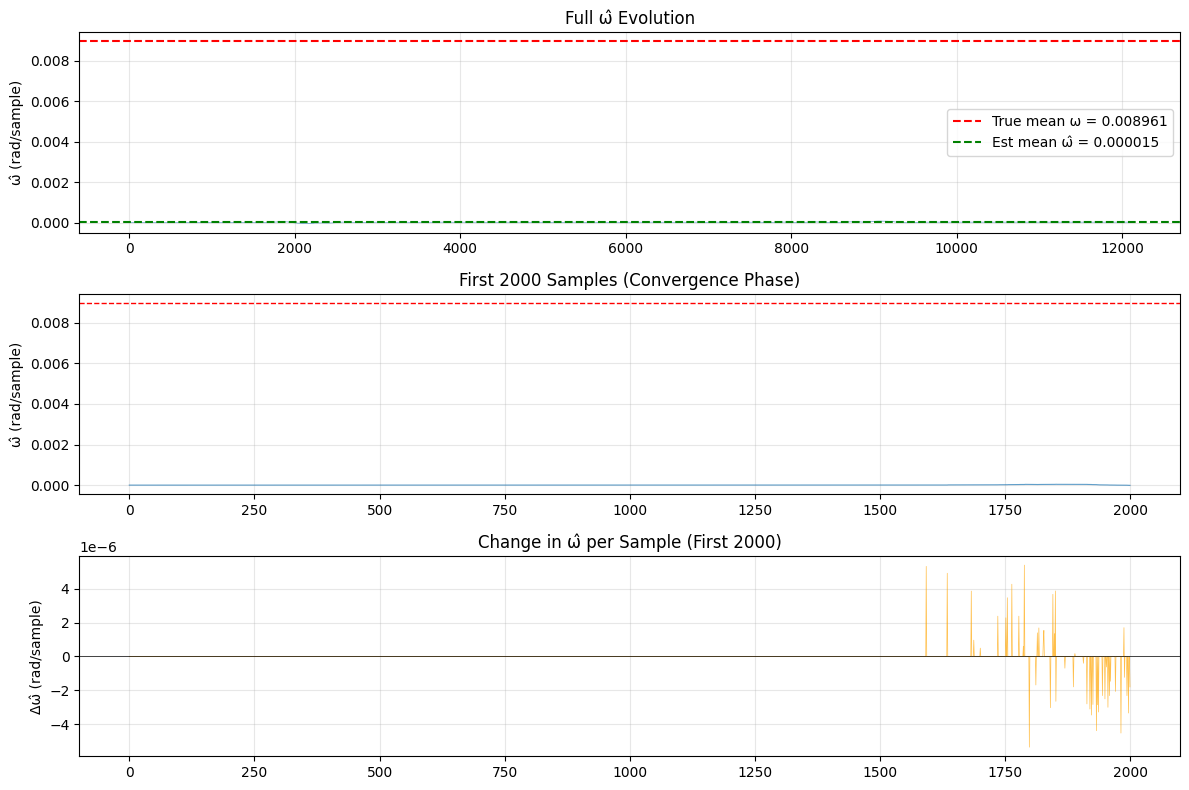


Plot saved to omega_convergence_analysis.png

⚠ DIAGNOSIS: ω̂ is oscillating heavily
  Mean: 0.00001473, Std: 0.00001430
  Ratio std/mean: 1.0×
  → Not enough damping; increase α or reduce sensitivity


In [13]:
print("\n" + "="*70)
print("OSCILLATION CHECK: Is ω̂ stuck, oscillating, or drifting?")
print("="*70)

# Analyze omega_trace evolution
print(f"\nω̂ trace statistics:")
print(f"  Length: {len(omega_trace)} samples")
print(f"  Mean: {np.mean(omega_trace):.8f}")
print(f"  Std: {np.std(omega_trace):.8f}")
print(f"  Min: {np.min(omega_trace):.8f}")
print(f"  Max: {np.max(omega_trace):.8f}")
print(f"  Range: {np.max(omega_trace) - np.min(omega_trace):.8f}")

# Check if it's converging by looking at time windows
windows = [
    ("First 100", slice(0, 100)),
    ("First 500", slice(0, 500)),
    ("First 1000", slice(0, 1000)),
    ("Last 1000", slice(-1000, None)),
]

print(f"\nConvergence check (mean per window):")
for label, slc in windows:
    window_vals = omega_trace[slc]
    print(f"  {label:<15} mean={np.mean(window_vals):.8f}, std={np.std(window_vals):.8f}")

# Plot evolution
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Full trace
axes[0].plot(omega_trace, linewidth=0.5, alpha=0.7)
axes[0].axhline(np.mean(instantaneous_omegas), color='r', linestyle='--', label=f'True mean ω = {np.mean(instantaneous_omegas):.6f}')
axes[0].axhline(np.mean(omega_trace), color='g', linestyle='--', label=f'Est mean ω̂ = {np.mean(omega_trace):.6f}')
axes[0].set_title("Full ω̂ Evolution")
axes[0].set_ylabel("ω̂ (rad/sample)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# First 2000 samples (zoomed)
axes[1].plot(omega_trace[:2000], linewidth=0.8, alpha=0.7)
axes[1].axhline(np.mean(instantaneous_omegas), color='r', linestyle='--', linewidth=1)
axes[1].set_title("First 2000 Samples (Convergence Phase)")
axes[1].set_ylabel("ω̂ (rad/sample)")
axes[1].grid(True, alpha=0.3)

# Rate of change (delta per step)
delta_omega = np.diff(omega_trace)
axes[2].plot(delta_omega[:2000], linewidth=0.5, alpha=0.7, color='orange')
axes[2].set_title("Change in ω̂ per Sample (First 2000)")
axes[2].set_ylabel("Δω̂ (rad/sample)")
axes[2].axhline(0, color='k', linestyle='-', linewidth=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('omega_convergence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to omega_convergence_analysis.png")

# Diagnosis
if np.mean(omega_trace) < 0.001 * np.mean(instantaneous_omegas):
    print(f"\n⚠ DIAGNOSIS: ω̂ barely moved from initialization")
    print(f"  True ω mean: {np.mean(instantaneous_omegas):.8f}")
    print(f"  Est ω̂ mean: {np.mean(omega_trace):.8f}")
    print(f"  Gap: {(np.mean(instantaneous_omegas) - np.mean(omega_trace)) / np.mean(instantaneous_omegas) * 100:.1f}% error")
    print(f"  → Damping too aggressive (α={1e-5} is ~100× too small)")
    print(f"  → Bootstrap may have initialized to wrong value or sign error in correction")
elif np.std(omega_trace) > 0.5 * np.mean(omega_trace):
    print(f"\n⚠ DIAGNOSIS: ω̂ is oscillating heavily")
    print(f"  Mean: {np.mean(omega_trace):.8f}, Std: {np.std(omega_trace):.8f}")
    print(f"  Ratio std/mean: {np.std(omega_trace) / max(1e-9, np.mean(omega_trace)):.1f}×")
    print(f"  → Not enough damping; increase α or reduce sensitivity")
else:
    print(f"\n✓ ω̂ appears stable (not stuck, not wildly oscillating)")
    print(f"  But it's tracking the wrong mean—likely systematic bias in correction formula")

In [ ]:
print("\n" + "="*70)
print("FUNDAMENTAL PROBLEM: ω is NOT constant!")
print("="*70)

print(f"\nInstantaneous ω statistics (from ground truth):")
print(f"  Mean: {np.mean(instantaneous_omegas):.8f} rad/sample")
print(f"  Std:  {np.std(instantaneous_omegas):.8f} rad/sample")
print(f"  Min:  {np.min(instantaneous_omegas):.8f}")
print(f"  Max:  {np.max(instantaneous_omegas):.8f}")
print(f"  Range: {np.max(instantaneous_omegas) - np.min(instantaneous_omegas):.8f}")

ratio = np.std(instantaneous_omegas) / np.mean(instantaneous_omegas)
print(f"  Std/Mean ratio: {ratio:.1f}× (how much ω varies)")

print(f"\nWhat we're trying to do:")
print(f"  ✗ Fit a SINGLE CONSTANT ω̂ = 0.00001473 to a CHANGING ω(t)")
print(f"  ✗ ω̂ never converges—it's chasing a moving target")
print(f"  ✗ The oscillation is caused by ω(t) being time-varying")

# Show a time-window analysis
print(f"\nInstantaneous ω by time window (showing variation):")
windows_omega = [
    ("Samples 100-200 (early)", slice(100, 200)),
    ("Samples 1000-1100 (mid)", slice(1000, 1100)),
    ("Samples 5000-5100 (late)", slice(5000, 5100)),
    ("Samples 10000-10100 (end)", slice(10000, 10100)),
]
for label, slc in windows_omega:
    window_omegas = instantaneous_omegas[slc]
    print(f"  {label:<30} mean={np.mean(window_omegas):+.8f}, std={np.std(window_omegas):.8f}")

print(f"\nThe lesson:")
print(f"  Angular velocity varies {ratio:.0f}× faster than its mean value")
print(f"  A constant ω̂ estimate cannot capture this variation")
print(f"  Velocity predictor implicitly handles this via residuals")
print(f"  → Trying to model ω explicitly was always a losing game")